# Session 05 — Sampling variability and the central limit theorem

Revision ID: S05-r1  
Estimated time: 75–90 minutes

**Question:** Why can two averages from the same software benchmark differ even when the benchmark procedure has not changed?

## Learning outcomes

1. Distinguish the distribution of individual measurements from a sampling distribution.
2. Use repeated random samples to estimate the variability of a sample mean.
3. Explain the relationship between standard error and sample size.
4. Describe what the central limit theorem does and does not claim.

Run cells from the top. This notebook creates a synthetic reference population of response-time measurements; the values are teaching data, not production evidence. Complete S05-E1–E3 and write interpretations in context.

## Define the experiment

One observation is one simulated load-test run, measured in milliseconds. The reference population is the complete array created below. We will repeatedly draw random samples **with replacement** from this fixed population.

- Population parameter: the mean of all reference runs, denoted `population_mean`.
- Sample statistic: the mean of one selected sample, denoted `sample_mean`.
- Sampling distribution: the distribution of a statistic across repeated samples of the same size.
- Standard error: the standard deviation of the sampling distribution of a statistic.

This setup is a model for random, independent runs. It does not repair selection bias, dependence, or changes in the benchmark protocol.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

population_rng = np.random.default_rng(20260515)
sampling_rng = np.random.default_rng(20260516)

## Create a right-skewed reference population

Response times are positive and may contain occasional long runs. A lognormal generator gives us a controllable, right-skewed population. `mean=np.log(180)` makes the theoretical median near 180 ms; `sigma=0.65` controls spread on the log scale. We know this generating setup because we chose it. Real latency data need not follow this model.

In [2]:
population = population_rng.lognormal(mean=np.log(180), sigma=0.65, size=100_000)
population_mean = population.mean()
population_sd = population.std(ddof=0)
population_summary = pd.Series({
    "number of runs": population.size,
    "population mean (ms)": population_mean,
    "population SD (ms)": population_sd,
    "population median (ms)": np.median(population),
})
display(population_summary.round(2))

number of runs            100000.00
population mean (ms)         222.33
population SD (ms)           161.09
population median (ms)       179.64
dtype: float64

### The distribution of individual runs

This histogram describes individual response-time values. It does not show how a sample mean varies. Keep the observational unit in mind: one plotted value is one run.

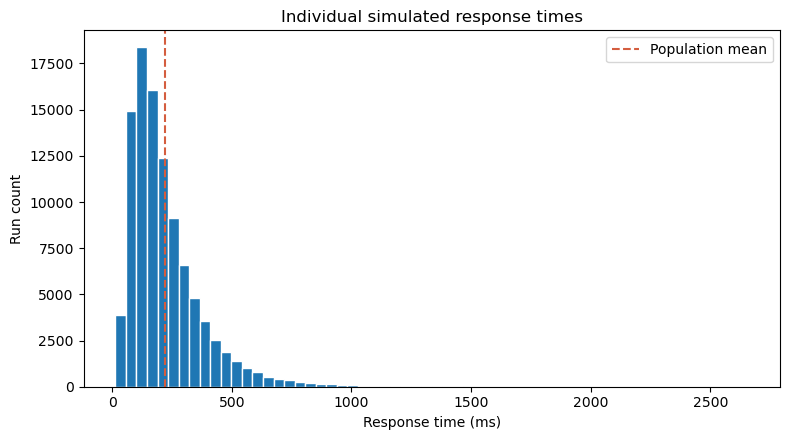

In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(population, bins=60, edgecolor="white")
ax.axvline(population_mean, color="#d45d3f", linestyle="--", label="Population mean")
ax.set(title="Individual simulated response times", xlabel="Response time (ms)", ylabel="Run count")
ax.legend()
fig.tight_layout()
plt.show()

## One sample, one estimate

A sample mean is a statistic, not the population parameter itself. Draw one sample of 20 runs and compare its average and sample SD with the fixed reference values. The sample SD (`ddof=1`) describes variation among individual values in this sample.

In [4]:
one_sample = sampling_rng.choice(population, size=20, replace=True)
one_sample_summary = pd.Series({
    "n": one_sample.size,
    "sample mean (ms)": one_sample.mean(),
    "sample SD (ms)": one_sample.std(ddof=1),
    "reference population mean (ms)": population_mean,
})
display(one_sample_summary.round(2))

n                                  20.00
sample mean (ms)                  253.25
sample SD (ms)                    172.08
reference population mean (ms)    222.33
dtype: float64

## Repeat the same sampling procedure

Now draw 3,000 samples for each selected sample size. Every row in a draw matrix is one possible sample; taking its row mean produces one possible estimate. The resulting array of means is a simulated sampling distribution.

In [5]:
replicates = 3_000
sample_sizes = [5, 20, 100]
sampling_means = {}
for sample_size in sample_sizes:
    draws = sampling_rng.choice(
        population, size=(replicates, sample_size), replace=True
    )
    sampling_means[sample_size] = draws.mean(axis=1)

sampling_summary = pd.DataFrame({
    sample_size: {
        "mean of sample means": values.mean(),
        "empirical SE (ms)": values.std(ddof=1),
        "theoretical SE (ms)": population_sd / np.sqrt(sample_size),
    }
    for sample_size, values in sampling_means.items()
}).T
display(sampling_summary.round(2))

,mean of sample means,empirical SE (ms),theoretical SE (ms)
5,222.20,70.50,72.04
20,221.94,37.49,36.02
100,222.51,16.60,16.11


### Compare the sampling distributions

The dashed line marks the fixed population mean. Compare center, spread, and shape. A histogram here counts simulated **sample means**, not individual runs.

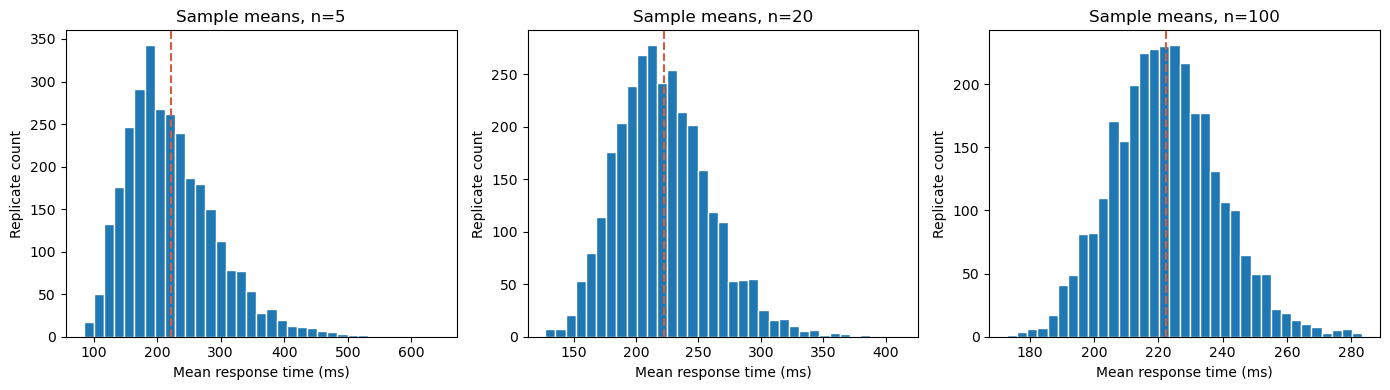

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, sample_size in zip(axes, sample_sizes):
    ax.hist(sampling_means[sample_size], bins=35, edgecolor="white")
    ax.axvline(population_mean, color="#d45d3f", linestyle="--")
    ax.set(title=f"Sample means, n={sample_size}", xlabel="Mean response time (ms)", ylabel="Replicate count")
fig.tight_layout()
plt.show()

## Standard error and sample size

For independent draws with finite population SD `population_sd`, the theoretical standard error of the sample mean is $\sigma/\sqrt{n}$. In practice, the population SD is usually unknown and sample SD is used to estimate it.

The standard error is measured in milliseconds. It describes the expected sample-to-sample spread of means; it is not the SD of individual runs and it is not the error in this one sample.

## S05-E1 — Name the quantities

Using the simulation above, identify the observational unit, population, population parameter, one sample statistic, and standard error. State which quantities remain fixed when a new sample is drawn and which can change. Include units where relevant.

In [7]:
# TODO: create a short table mapping each requested term to its value or description.
e1_response = None

## S05-E2 — Explain the effect of n

Use the simulated histograms and `sampling_summary`. Compare $n=5$ with $n=100$. Describe how the center, spread, and shape of the sample-mean distributions change. Compare the empirical SE with $\sigma/\sqrt{n}$ and explain why small differences are expected.

In [8]:
# TODO: write a short interpretation with sample sizes and milliseconds.
e2_response = ""

## S05-E3 — Check the CLT claim

Run a second simulation with sample sizes 10, 40, and 160, using at least 1,000 replicates per size. Compare the sampling distributions. In two or three sentences, explain which distribution tends to become more nearly symmetric and which distribution does not become normal merely because n increases. State one assumption or limitation of this simulation.

In [9]:
second_simulation = None
# TODO: simulate sample means for n=10, 40, and 160, then compare them in a plot.
if second_simulation is not None:
    display(second_simulation)

## Synthesis and exit ticket

The sampling distribution concerns a statistic over repeated samples. Increasing n usually reduces the standard error of the mean at a square-root rate. The CLT concerns the shape of this sampling distribution, not the shape of raw observations.

**Exit ticket:** A benchmark average from 80 runs is usually more stable than one from 8 runs. Name one problem that 80 runs cannot fix.

A valid limitation is selection bias, dependence among runs, measurement changes, or the fact that the simulated population is not a real system.